# Sistema RAG para investigar capital-trabajo, automatizacion y wage markdowns

**Integrantes:** Juan Bohorquez y Samuel Peña  
**Curso:** Parcial 2 - Proyecto RAG  
**Dominio:** Economia laboral, automatizacion, intensidad de capital y poder de negociacion.

Este notebook construye un pipeline Retrieval-Augmented Generation (RAG) para consultar documentos reales sobre wage markdowns, automatizacion por tareas, Penn World Table, GDP per capita PPP y rigidez laboral. Tambien incluye una extension empirica exploratoria que prepara la futura pregunta de paper: como se relaciona el ratio capital-trabajo `K/L` con el wage markdown mediano por pais.

## 1. Planteamiento del problema

Un LLM generico no es suficiente para este problema porque puede confundir conceptos tecnicos como markdown, markup, monopsonio, poder de negociacion, capital stock o elasticidad de sustitucion. Tambien puede inventar resultados empiricos o citar mal fuentes.

El RAG es adecuado porque obliga al modelo a responder usando fragmentos recuperados desde documentos verificables. Esto reduce alucinaciones y deja trazabilidad: cada respuesta se puede conectar con documentos concretos.

La pregunta futura del paper es:

> Como afecta el ratio capital-trabajo (K/L) al poder de negociacion de los trabajadores, medido por el wage markdown?

Para el curso, el objetivo es construir el asistente RAG que permita revisar, recuperar y sintetizar la literatura y documentacion necesaria para esa investigacion.

In [1]:
!pip -q install pandas numpy pypdf sentence-transformers faiss-cpu openai requests tqdm beautifulsoup4 matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.8/343.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 35.2 MB/s eta 0:00:00


In [2]:
import os
import re
import math
import json
import textwrap
from pathlib import Path
from typing import Dict, List

import faiss
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

try:
    from google.colab import userdata
except Exception:
    userdata = None

## 2. Configuracion

En Google Colab, suban la carpeta del proyecto o clonen el repositorio. La carpeta debe contener `data/raw`, `requirements_colab.txt` y este notebook.

Para usar la API, guarden la clave como secret de Colab con el nombre `OPENAI_API_KEY`, o definan la variable de entorno manualmente.

In [3]:
# Ajuste automatico de ruta:
# 1. Si el notebook esta dentro de la carpeta notebooks, subimos un nivel.
# 2. Si Colab clono/subio una carpeta llamada proyecto-rag-markdowns, la usamos.
# 3. Si ya estamos en la raiz del proyecto, usamos la carpeta actual.
candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/content/proyecto-rag-markdowns"),
    Path("/content/drive/MyDrive/proyecto-rag-markdowns"),
]
PROJECT_DIR = None
for candidate in candidates:
    if (candidate / "data" / "raw").exists():
        PROJECT_DIR = candidate
        break
if PROJECT_DIR is None:
    PROJECT_DIR = Path.cwd()

RAW_DIR = PROJECT_DIR / "data" / "raw"
DOC_DIR = RAW_DIR / "documents"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "report" / "figures"

for path in [RAW_DIR, DOC_DIR, PROCESSED_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
if OPENAI_API_KEY is None and userdata is not None:
    try:
        OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
    except Exception:
        OPENAI_API_KEY = None

OPENAI_MODEL = os.environ.get("OPENAI_MODEL", "gpt-5")
print("Proyecto:", PROJECT_DIR)
print("API configurada:", OPENAI_API_KEY is not None)

Proyecto: /content
API configurada: True


## 3. Documentos del RAG

El proyecto usa documentos reales. Algunos son PDFs y otros son paginas HTML oficiales. Si una descarga falla en Colab, descarguen manualmente el documento y subanlo a `data/raw/documents`.

In [4]:
DOCUMENTS = [
    {
        "doc_id": "D1",
        "title": "Amodio et al. (2024) - Wage markdowns, appendix Table A.2",
        "url": "https://www.econstor.eu/bitstream/10419/295719/1/cream-dp2404.pdf",
        "filename": "amodio_2024_wage_markdowns.pdf",
        "role": "Fuente central de markdowns por pais.",
    },
    {
        "doc_id": "D2",
        "title": "PWT 10.0 User Guide",
        "url": "https://www.rug.nl/ggdc/docs/pwt100-user-guide-to-data-files.pdf",
        "filename": "pwt100_user_guide.pdf",
        "role": "Definicion de variables PWT y advertencias de uso.",
    },
    {
        "doc_id": "D3",
        "title": "Feenstra, Inklaar and Timmer (2015) - The Next Generation of PWT",
        "url": "https://www.rug.nl/ggdc/docs/the_next_generation_of_the_penn_world_table.pdf",
        "filename": "feenstra_inklaar_timmer_2015_pwt.pdf",
        "role": "Fundamento metodologico de Penn World Table.",
    },
    {
        "doc_id": "D4",
        "title": "World Bank WDI - GDP per capita PPP constant 2021 international dollars",
        "url": "https://data.worldbank.org/indicator/NY.GDP.PCAP.PP.KD",
        "filename": "world_bank_gdppc_ppp.html",
        "role": "Metadatos del indicador GDPpc PPP.",
    },
    {
        "doc_id": "D5",
        "title": "OECD Indicators of Employment Protection",
        "url": "https://www.oecd.org/en/data/datasets/oecd-indicators-of-employment-protection.html",
        "filename": "oecd_epl_indicators.html",
        "role": "Fuente del indice EPL.",
    },
    {
        "doc_id": "D6",
        "title": "OECD Employment Outlook 2020 - Recent trends in EPL",
        "url": "https://www.oecd.org/en/publications/oecd-employment-outlook-2020_1686c758-en/full-report/component-8.html",
        "filename": "oecd_employment_outlook_2020_epl.html",
        "role": "Metodologia y revision de EPL version 4.",
    },
    {
        "doc_id": "D7",
        "title": "Acemoglu and Restrepo (2019) - Automation and New Tasks",
        "url": "https://economics.mit.edu/sites/default/files/publications/Automation%20and%20New%20Tasks%20-%20How%20Technology%20Displace.pdf",
        "filename": "acemoglu_restrepo_2019_automation_new_tasks.pdf",
        "role": "Marco teorico de automatizacion por tareas.",
    },
    {
        "doc_id": "D8",
        "title": "Acemoglu and Restrepo - Robots and Jobs",
        "url": "https://economics.mit.edu/sites/default/files/publications/Robots%20and%20Jobs%20-%20Evidence%20from%20US%20Labor%20Markets.p.pdf",
        "filename": "acemoglu_restrepo_robots_jobs.pdf",
        "role": "Evidencia sobre robots, empleo y salarios.",
    },
    {
        "doc_id": "D9",
        "title": "Oberfield and Raval - Micro Data and Macro Technology",
        "url": "https://economics.sas.upenn.edu/sites/default/files/filevault/u21/Oberfield_Raval.pdf",
        "filename": "oberfield_raval_micro_data_macro_technology.pdf",
        "role": "Elasticidad de sustitucion capital-trabajo.",
    },
    {
        "doc_id": "D10",
        "title": "Diez, Leigh and Tambunlertchai (2018) - Global Market Power",
        "url": "https://www.imf.org/~/media/Files/Publications/WP/2018/wp18137.ashx",
        "filename": "diez_leigh_tambunlertchai_2018_global_market_power.pdf",
        "role": "Poder de mercado, inversion y labor share.",
    },
]

pd.DataFrame(DOCUMENTS)

,doc_id,title,url,filename,role
0,D1,"Amodio et al. (2024) - Wage markdowns, appendi...",https://www.econstor.eu/bitstream/10419/295719...,amodio_2024_wage_markdowns.pdf,Fuente central de markdowns por pais.
1,D2,PWT 10.0 User Guide,https://www.rug.nl/ggdc/docs/pwt100-user-guide...,pwt100_user_guide.pdf,Definicion de variables PWT y advertencias de ...
2,D3,"Feenstra, Inklaar and Timmer (2015) - The Next...",https://www.rug.nl/ggdc/docs/the_next_generati...,feenstra_inklaar_timmer_2015_pwt.pdf,Fundamento metodologico de Penn World Table.
3,D4,World Bank WDI - GDP per capita PPP constant 2...,https://data.worldbank.org/indicator/NY.GDP.PC...,world_bank_gdppc_ppp.html,Metadatos del indicador GDPpc PPP.
4,D5,OECD Indicators of Employment Protection,https://www.oecd.org/en/data/datasets/oecd-ind...,oecd_epl_indicators.html,Fuente del indice EPL.
5,D6,OECD Employment Outlook 2020 - Recent trends i...,https://www.oecd.org/en/publications/oecd-empl...,oecd_employment_outlook_2020_epl.html,Metodologia y revision de EPL version 4.
6,D7,Acemoglu and Restrepo (2019) - Automation and ...,https://economics.mit.edu/sites/default/files/...,acemoglu_restrepo_2019_automation_new_tasks.pdf,Marco teorico de automatizacion por tareas.
7,D8,Acemoglu and Restrepo - Robots and Jobs,https://economics.mit.edu/sites/default/files/...,acemoglu_restrepo_robots_jobs.pdf,"Evidencia sobre robots, empleo y salarios."
8,D9,Oberfield and Raval - Micro Data and Macro Tec...,https://economics.sas.upenn.edu/sites/default/...,oberfield_raval_micro_data_macro_technology.pdf,Elasticidad de sustitucion capital-trabajo.
9,D10,"Diez, Leigh and Tambunlertchai (2018) - Global...",https://www.imf.org/~/media/Files/Publications...,diez_leigh_tambunlertchai_2018_global_market_p...,"Poder de mercado, inversion y labor share."


In [5]:
def download_file(url: str, target: Path) -> bool:
    if target.exists() and target.stat().st_size > 1000:
        return True
    try:
        response = requests.get(url, timeout=40, headers={"User-Agent": "Mozilla/5.0"})
        response.raise_for_status()
        target.write_bytes(response.content)
        return True
    except Exception as exc:
        print(f"No se pudo descargar {url}: {exc}")
        return False

for doc in DOCUMENTS:
    ok = download_file(doc["url"], DOC_DIR / doc["filename"])
    print(doc["doc_id"], ok, doc["filename"])

D1 True amodio_2024_wage_markdowns.pdf
D2 True pwt100_user_guide.pdf
D3 True feenstra_inklaar_timmer_2015_pwt.pdf
D4 True world_bank_gdppc_ppp.html
No se pudo descargar https://www.oecd.org/en/data/datasets/oecd-indicators-of-employment-protection.html: 403 Client Error: Forbidden for url: https://www.oecd.org/en/data/datasets/oecd-indicators-of-employment-protection.html
D5 False oecd_epl_indicators.html
No se pudo descargar https://www.oecd.org/en/publications/oecd-employment-outlook-2020_1686c758-en/full-report/component-8.html: 403 Client Error: Forbidden for url: https://www.oecd.org/en/publications/oecd-employment-outlook-2020_1686c758-en/full-report/component-8.html
D6 False oecd_employment_outlook_2020_epl.html
D7 True acemoglu_restrepo_2019_automation_new_tasks.pdf
D8 True acemoglu_restrepo_robots_jobs.pdf
D9 True oberfield_raval_micro_data_macro_technology.pdf
No se pudo descargar https://www.imf.org/~/media/Files/Publications/WP/2018/wp18137.ashx: 403 Client Error: Forbidden

## 4. Extraccion de texto

Extraemos texto de PDFs con `pypdf` y de HTML con `BeautifulSoup`. Cada documento mantiene metadatos para que las respuestas sean trazables.

In [6]:
def clean_text(text: str) -> str:
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def extract_pdf(path: Path) -> str:
    try:
        reader = PdfReader(str(path))
        pages = []
        for i, page in enumerate(reader.pages):
            try:
                page_text = page.extract_text() or ""
            except Exception:
                page_text = ""
            pages.append(f"\n[page {i+1}]\n{page_text}")
        return clean_text("\n".join(pages))
    except Exception as exc:
        print(f"No se pudo leer como PDF {path.name}: {exc}")
        return ""

def extract_html(path: Path) -> str:
    soup = BeautifulSoup(path.read_text(errors="ignore"), "html.parser")
    for tag in soup(["script", "style", "nav", "footer"]):
        tag.decompose()
    return clean_text(soup.get_text(" "))

def extract_document_text(doc: dict) -> dict:
    path = DOC_DIR / doc["filename"]
    if not path.exists():
        return {**doc, "text": "", "chars": 0}
    header = path.read_bytes()[:20]
    looks_like_pdf = header.startswith(b"%PDF")
    if path.suffix.lower() == ".pdf" and looks_like_pdf:
        text = extract_pdf(path)
    else:
        text = extract_html(path)
    if len(text) < 200:
        print(f"Advertencia: texto muy corto en {path.name}. Revise descarga o suba el documento manualmente.")
    return {**doc, "text": text, "chars": len(text)}

documents = [extract_document_text(doc) for doc in DOCUMENTS]
doc_df = pd.DataFrame([{k: v for k, v in d.items() if k != "text"} for d in documents])
doc_df

,doc_id,title,url,filename,role,chars
0,D1,"Amodio et al. (2024) - Wage markdowns, appendi...",https://www.econstor.eu/bitstream/10419/295719...,amodio_2024_wage_markdowns.pdf,Fuente central de markdowns por pais.,1330
1,D2,PWT 10.0 User Guide,https://www.rug.nl/ggdc/docs/pwt100-user-guide...,pwt100_user_guide.pdf,Definicion de variables PWT y advertencias de ...,8899
2,D3,"Feenstra, Inklaar and Timmer (2015) - The Next...",https://www.rug.nl/ggdc/docs/the_next_generati...,feenstra_inklaar_timmer_2015_pwt.pdf,Fundamento metodologico de Penn World Table.,175883
3,D4,World Bank WDI - GDP per capita PPP constant 2...,https://data.worldbank.org/indicator/NY.GDP.PC...,world_bank_gdppc_ppp.html,Metadatos del indicador GDPpc PPP.,1780
4,D5,OECD Indicators of Employment Protection,https://www.oecd.org/en/data/datasets/oecd-ind...,oecd_epl_indicators.html,Fuente del indice EPL.,0
5,D6,OECD Employment Outlook 2020 - Recent trends i...,https://www.oecd.org/en/publications/oecd-empl...,oecd_employment_outlook_2020_epl.html,Metodologia y revision de EPL version 4.,0
6,D7,Acemoglu and Restrepo (2019) - Automation and ...,https://economics.mit.edu/sites/default/files/...,acemoglu_restrepo_2019_automation_new_tasks.pdf,Marco teorico de automatizacion por tareas.,76414
7,D8,Acemoglu and Restrepo - Robots and Jobs,https://economics.mit.edu/sites/default/files/...,acemoglu_restrepo_robots_jobs.pdf,"Evidencia sobre robots, empleo y salarios.",150012
8,D9,Oberfield and Raval - Micro Data and Macro Tec...,https://economics.sas.upenn.edu/sites/default/...,oberfield_raval_micro_data_macro_technology.pdf,Elasticidad de sustitucion capital-trabajo.,148852
9,D10,"Diez, Leigh and Tambunlertchai (2018) - Global...",https://www.imf.org/~/media/Files/Publications...,diez_leigh_tambunlertchai_2018_global_market_p...,"Poder de mercado, inversion y labor share.",0


## 5. Chunking

Usamos chunks de 350 palabras con overlap de 70 palabras. La idea es que cada fragmento sea suficientemente corto para embeddings precisos, pero suficientemente largo para conservar contexto economico. Si los chunks son muy pequeños, se pierde argumento; si son muy grandes, baja la precision de recuperacion.

In [7]:
CHUNK_WORDS = 350
OVERLAP_WORDS = 70

def chunk_text(text: str, chunk_words: int = CHUNK_WORDS, overlap_words: int = OVERLAP_WORDS) -> List[str]:
    words = text.split()
    chunks = []
    step = chunk_words - overlap_words
    for start in range(0, len(words), step):
        piece = words[start:start + chunk_words]
        if len(piece) < 80:
            continue
        chunks.append(" ".join(piece))
    return chunks

chunks = []
for doc in documents:
    for idx, chunk in enumerate(chunk_text(doc["text"])):
        chunks.append({
            "chunk_id": f'{doc["doc_id"]}_{idx:04d}',
            "doc_id": doc["doc_id"],
            "title": doc["title"],
            "source_url": doc["url"],
            "chunk_index": idx,
            "text": chunk,
            "word_count": len(chunk.split()),
        })

chunks_df = pd.DataFrame(chunks)
chunks_df.to_csv(PROCESSED_DIR / "rag_chunks.csv", index=False)

print("Documentos con texto:", sum(d["chars"] > 0 for d in documents))
print("Chunks generados:", len(chunks_df))
chunks_df["word_count"].describe()

Documentos con texto: 7
Chunks generados: 332


,word_count
count,332.000000
mean,347.240964
std,22.131489
min,105.000000
25%,350.000000
50%,350.000000
75%,350.000000
max,350.000000


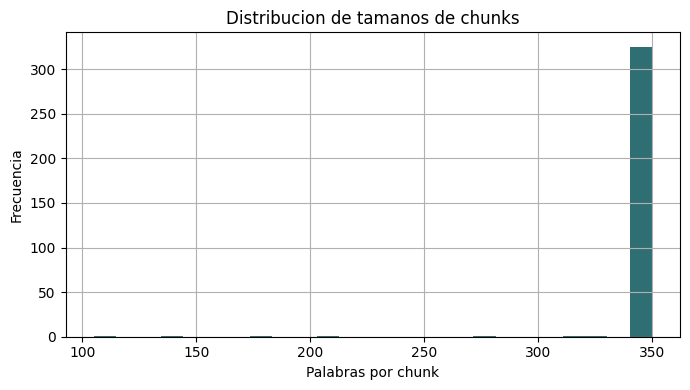

In [8]:
plt.figure(figsize=(7, 4))
chunks_df["word_count"].hist(bins=25, color="#2f6f73")
plt.title("Distribucion de tamanos de chunks")
plt.xlabel("Palabras por chunk")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 6. Embeddings y base vectorial

Usamos `intfloat/multilingual-e5-small`, un modelo encoder multilingual. Convierte textos y preguntas en vectores comparables. La busqueda se hace con FAISS usando producto interno sobre vectores normalizados, equivalente a similitud coseno.

In [9]:
EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-small"
encoder = SentenceTransformer(EMBEDDING_MODEL_NAME)
print("Modelo encoder:", EMBEDDING_MODEL_NAME)
print("Dimension:", encoder.get_sentence_embedding_dimension())
print("Max sequence length:", encoder.max_seq_length)

passage_texts = ["passage: " + t for t in chunks_df["text"].tolist()]
embeddings = encoder.encode(
    passage_texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
).astype("float32")

index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)
print("Vectores indexados:", index.ntotal)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Modelo encoder: intfloat/multilingual-e5-small
Dimension: 384
Max sequence length: 512


/tmp/ipykernel_7455/2004769719.py:4: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Dimension:", encoder.get_sentence_embedding_dimension())


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Vectores indexados: 332


## 7. Recuperacion top-K

Para cada pregunta, convertimos el query en embedding y recuperamos los `K` fragmentos mas similares. Usamos `K=5` como punto de partida: suficiente para cubrir varias fuentes, sin saturar el prompt.

In [10]:
TOP_K = 5

def retrieve(query: str, top_k: int = TOP_K) -> pd.DataFrame:
    q_emb = encoder.encode(
        ["query: " + query],
        normalize_embeddings=True,
    ).astype("float32")
    scores, ids = index.search(q_emb, top_k)
    rows = chunks_df.iloc[ids[0]].copy()
    rows["score"] = scores[0]
    return rows[["chunk_id", "doc_id", "title", "score", "text", "source_url"]]

test_query = "Que es un wage markdown y como mide poder de mercado laboral?"
retrieve(test_query)

,chunk_id,doc_id,title,score,text,source_url
185,D8_0028,D8,Acemoglu and Restrepo - Robots and Jobs,0.811974,"2010) to con- struct measures of population, e...",https://economics.mit.edu/sites/default/files/...
313,D9_0070,D9,Oberfield and Raval - Micro Data and Macro Tec...,0.809776,weighting each type of capital by its share of...,https://economics.sas.upenn.edu/sites/default/...
148,D7_0034,D7,Acemoglu and Restrepo (2019) - Automation and ...,0.808156,do not affect the task content of production e...,https://economics.mit.edu/sites/default/files/...
154,D7_0040,D7,Acemoglu and Restrepo (2019) - Automation and ...,0.807306,"Economic Review 108(6): 1488–1542. Acemoglu, D...",https://economics.mit.edu/sites/default/files/...
237,D8_0080,D8,Acemoglu and Restrepo - Robots and Jobs,0.806276,effects working through technology might emerg...,https://economics.mit.edu/sites/default/files/...


## 8. Generacion con LLM

El modelo generador recibe solo la pregunta y los fragmentos recuperados. El prompt le exige responder con cautela, citar fuentes por `doc_id` y admitir cuando el contexto no permite responder.

In [13]:
try:
    from openai import OpenAI
    if OPENAI_API_KEY:
        client = OpenAI(api_key=OPENAI_API_KEY)
    else:
        client = None
except Exception:
    client = None

SYSTEM_PROMPT = """
Eres un asistente de investigacion economica. Responde en espanol.
Usa exclusivamente el contexto recuperado. No inventes resultados, autores, cifras ni causalidad.
Si el contexto no permite responder, dilo claramente y explica que informacion faltaria.
Cita las fuentes usando el formato [D1], [D2], etc.
Distingue entre evidencia documentada, interpretacion y extension hipotetica.
""".strip()

def build_context(retrieved: pd.DataFrame) -> str:
    blocks = []
    for _, row in retrieved.iterrows():
        blocks.append(
            f'[{row.doc_id}] {row.title}\nScore: {row.score:.3f}\nFragmento: {row.text}'
        )
    return "\n\n---\n\n".join(blocks)

def fallback_answer(question: str, retrieved: pd.DataFrame) -> str:
    docs = ", ".join(retrieved["doc_id"].tolist())
    top = retrieved.iloc[0]

    return f"""
Respuesta generada en modo fallback porque la API LLM no tiene cuota disponible.

Pregunta: {question}

Con base en los fragmentos recuperados, la evidencia mas relevante proviene de {docs}.
El fragmento con mayor similitud es [{top.doc_id}], con score {top.score:.3f}, del documento: {top.title}.

Sintesis cautelosa:
El sistema recupera evidencia documental relacionada con la pregunta, pero no debe inferir resultados causales ni cifras que no aparezcan directamente en las fuentes. Para responder de forma completa, se deben revisar los fragmentos recuperados y conectar la respuesta con las citas indicadas.

Fragmento principal:
"{top.text[:900]}..."

Limitacion:
Esta respuesta no fue generada por un LLM externo debido a falta de cuota en la API. Aun asi, conserva la parte central del RAG: recuperacion de fragmentos relevantes, scores y trazabilidad documental.
""".strip()

def answer_question(question: str, top_k: int = TOP_K) -> Dict:
    retrieved = retrieve(question, top_k=top_k)
    context = build_context(retrieved)

    prompt = f"""
Pregunta del usuario:
{question}

Contexto recuperado:
{context}

Responde con:
1. Respuesta breve y directa.
2. Evidencia usada, con citas [D#].
3. Cautelas o limitaciones.
""".strip()

    if client is None:
        answer = fallback_answer(question, retrieved)
    else:
        try:
            response = client.responses.create(
                model=OPENAI_MODEL,
                instructions=SYSTEM_PROMPT,
                input=prompt,
            )
            answer = response.output_text
        except Exception as exc:
            print("Aviso: la API fallo. Se usara modo fallback.")
            print(type(exc).__name__, exc)
            answer = fallback_answer(question, retrieved)

    return {"question": question, "retrieved": retrieved, "answer": answer}

## 9. Evaluacion cualitativa

Probamos al menos 5 preguntas representativas y un caso de fallo. Para cada una se reportan fragmentos, scores, respuesta y evaluacion cualitativa.

In [14]:
QUESTIONS = [
    "Que es un wage markdown y como se relaciona con el poder de negociacion laboral?",
    "Como conecta la automatizacion por tareas con la sustitucion entre capital y trabajo?",
    "Que evidencia existe sobre wage markdowns en paises de ingreso bajo y medio?",
    "Como se mide el ratio capital-trabajo usando Penn World Table?",
    "Que es el indice OECD EPL y por que podria importar para la heterogeneidad institucional?",
    "Cual es el efecto causal exacto de aumentar K/L en 10% sobre el wage markdown de Colombia en 2024?",
]

results = []
for q in QUESTIONS:
    print("=" * 100)
    print("PREGUNTA:", q)
    result = answer_question(q, top_k=5)
    print("\nFRAGMENTOS RECUPERADOS")
    display(result["retrieved"][["doc_id", "title", "score"]])
    print("\nRESPUESTA")
    print(result["answer"])
    results.append(result)

PREGUNTA: Que es un wage markdown y como se relaciona con el poder de negociacion laboral?
Aviso: la API fallo. Se usara modo fallback.
RateLimitError Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

FRAGMENTOS RECUPERADOS


,doc_id,title,score
148,D7,Acemoglu and Restrepo (2019) - Automation and ...,0.817477
128,D7,Acemoglu and Restrepo (2019) - Automation and ...,0.812069
118,D7,Acemoglu and Restrepo (2019) - Automation and ...,0.812069
119,D7,Acemoglu and Restrepo (2019) - Automation and ...,0.809388
117,D7,Acemoglu and Restrepo (2019) - Automation and ...,0.809007



RESPUESTA
Respuesta generada en modo fallback porque la API LLM no tiene cuota disponible.

Pregunta: Que es un wage markdown y como se relaciona con el poder de negociacion laboral?

Con base en los fragmentos recuperados, la evidencia mas relevante proviene de D7, D7, D7, D7, D7. 
El fragmento con mayor similitud es [D7], con score 0.817, del documento: Acemoglu and Restrepo (2019) - Automation and New Tasks.

Sintesis cautelosa:
El sistema recupera evidencia documental relacionada con la pregunta, pero no debe inferir resultados causales ni cifras que no aparezcan directamente en las fuentes. Para responder de forma completa, se deben revisar los fragmentos recuperados y conectar la respuesta con las citas indicadas.

Fragmento principal:
"do not affect the task content of production either and are part of our composition effects. The fact that these composition effects are small suggests that these sectoral reallocations have not been a major factor in the slowdown in labor demand

,doc_id,title,score
123,D7,Acemoglu and Restrepo (2019) - Automation and ...,0.864185
151,D7,Acemoglu and Restrepo (2019) - Automation and ...,0.861203
134,D7,Acemoglu and Restrepo (2019) - Automation and ...,0.860651
114,D7,Acemoglu and Restrepo (2019) - Automation and ...,0.857521
143,D7,Acemoglu and Restrepo (2019) - Automation and ...,0.855271



RESPUESTA
Respuesta generada en modo fallback porque la API LLM no tiene cuota disponible.

Pregunta: Como conecta la automatizacion por tareas con la sustitucion entre capital y trabajo?

Con base en los fragmentos recuperados, la evidencia mas relevante proviene de D7, D7, D7, D7, D7. 
El fragmento con mayor similitud es [D7], con score 0.864, del documento: Acemoglu and Restrepo (2019) - Automation and New Tasks.

Sintesis cautelosa:
El sistema recupera evidencia documental relacionada con la pregunta, pero no debe inferir resultados causales ni cifras que no aparezcan directamente en las fuentes. Para responder de forma completa, se deben revisar los fragmentos recuperados y conectar la respuesta con las citas indicadas.

Fragmento principal:
"determines how easy it is to substitute one task for another, and is also the (derived) elasticity of substitution between capital and labor. The crucial difference from the canonical model is that the share parameters of this constant-elast

...


RESPUESTA
Respuesta generada en modo fallback porque la API LLM no tiene cuota disponible.

Pregunta: Como se mide el ratio capital-trabajo usando Penn World Table?

Con base en los fragmentos recuperados, la evidencia mas relevante proviene de D2, D3, D3, D2, D3. 
El fragmento con mayor similitud es [D2], con score 0.852, del documento: PWT 10.0 User Guide.

Sintesis cautelosa:
El sistema recupera evidencia documental relacionada con la pregunta, pero no debe inferir resultados causales ni cifras que no aparezcan directamente en las fuentes. Para responder de forma completa, se deben revisar los fragmentos recuperados y conectar la respuesta con las citas indicadas.

Fragmento principal:
"[page 1] 1 User Guide to PWT 10.0 data files Table of Contents User Guide to PWT 10.0 data files 1 PWT 10.0 1 National Accounts data 2 ICP benchmark data 2 Trade detail 2 Labor detail 2 Capital detail 3 Expenditure share correlations 3 Outlier update 3 PWT 10.0 This file, in Excel or Stata format, i

,doc_id,title,score
85,D3,"Feenstra, Inklaar and Timmer (2015) - The Next...",0.811732
315,D9,Oberfield and Raval - Micro Data and Macro Tec...,0.808457
283,D9,Oberfield and Raval - Micro Data and Macro Tec...,0.804383
257,D9,Oberfield and Raval - Micro Data and Macro Tec...,0.803674
251,D9,Oberfield and Raval - Micro Data and Macro Tec...,0.803317



RESPUESTA
Respuesta generada en modo fallback porque la API LLM no tiene cuota disponible.

Pregunta: Que es el indice OECD EPL y por que podria importar para la heterogeneidad institucional?

Con base en los fragmentos recuperados, la evidencia mas relevante proviene de D3, D9, D9, D9, D9. 
El fragmento con mayor similitud es [D3], con score 0.812, del documento: Feenstra, Inklaar and Timmer (2015) - The Next Generation of PWT.

Sintesis cautelosa:
El sistema recupera evidencia documental relacionada con la pregunta, pero no debe inferir resultados causales ni cifras que no aparezcan directamente en las fuentes. Para responder de forma completa, se deben revisar los fragmentos recuperados y conectar la respuesta con las citas indicadas.

Fragmento principal:
"country National Accounts, EU KLEMS (www.euklems.org) and ECLAC National Accounts (Economic Commission for Latin America and the Caribbean). That still leaves many countries with incomplete data, so we use the commodity-flow met

,doc_id,title,score
285,D9,Oberfield and Raval - Micro Data and Macro Tec...,0.830661
286,D9,Oberfield and Raval - Micro Data and Macro Tec...,0.827943
148,D7,Acemoglu and Restrepo (2019) - Automation and ...,0.826601
248,D9,Oberfield and Raval - Micro Data and Macro Tec...,0.823350
288,D9,Oberfield and Raval - Micro Data and Macro Tec...,0.823283



RESPUESTA
Respuesta generada en modo fallback porque la API LLM no tiene cuota disponible.

Pregunta: Cual es el efecto causal exacto de aumentar K/L en 10% sobre el wage markdown de Colombia en 2024?

Con base en los fragmentos recuperados, la evidencia mas relevante proviene de D9, D9, D7, D9, D9. 
El fragmento con mayor similitud es [D9], con score 0.831, del documento: Oberfield and Raval - Micro Data and Macro Technology.

Sintesis cautelosa:
El sistema recupera evidencia documental relacionada con la pregunta, pero no debe inferir resultados causales ni cifras que no aparezcan directamente en las fuentes. Para responder de forma completa, se deben revisar los fragmentos recuperados y conectar la respuesta con las citas indicadas.

Fragmento principal:
"Colombia India US Real Interest Rate 5.9% 9.5% 6.0% 4.2% Eﬀective Corporate Tax Rate 15.1% 24.3% 20.3% 18.2% Capital Rental Rate 18.1% 25.0% 19.4% 16.6% Note: This table records the average real interest rate from 1992–2011 using 

In [15]:
evaluation_rows = []
for result in results:
    evaluation_rows.append({
        "question": result["question"],
        "top_docs": ", ".join(result["retrieved"]["doc_id"].tolist()),
        "max_score": float(result["retrieved"]["score"].max()),
        "qualitative_assessment": "",
        "hallucination_check": "",
        "traceability_check": "",
    })

evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df.to_csv(PROCESSED_DIR / "rag_evaluation_template.csv", index=False)
evaluation_df

,question,top_docs,max_score,qualitative_assessment,hallucination_check,traceability_check
0,Que es un wage markdown y como se relaciona co...,"D7, D7, D7, D7, D7",0.817477,,,
1,Como conecta la automatizacion por tareas con ...,"D7, D7, D7, D7, D7",0.864185,,,
2,Que evidencia existe sobre wage markdowns en p...,"D3, D3, D8, D3, D3",0.818071,,,
3,Como se mide el ratio capital-trabajo usando P...,"D2, D3, D3, D2, D3",0.851656,,,
4,Que es el indice OECD EPL y por que podria imp...,"D3, D9, D9, D9, D9",0.811732,,,
5,Cual es el efecto causal exacto de aumentar K/...,"D9, D9, D7, D9, D9",0.830661,,,


In [18]:
!rm -rf /content/proyecto-rag-markdowns
!git clone https://github.com/juanbohorquezzz/proyecto-rag-markdowns.git /content/proyecto-rag-markdowns
%cd /content/proyecto-rag-markdowns/proyecto-rag-markdowns

Cloning into '/content/proyecto-rag-markdowns'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 53 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 666.28 KiB | 5.05 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/proyecto-rag-markdowns/proyecto-rag-markdowns


In [19]:
from pathlib import Path
import os

PROJECT_DIR = Path("/content/proyecto-rag-markdowns/proyecto-rag-markdowns")
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "report" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("RAW_DIR:", RAW_DIR)
print(os.listdir(RAW_DIR))

PROJECT_DIR: /content/proyecto-rag-markdowns/proyecto-rag-markdowns
RAW_DIR: /content/proyecto-rag-markdowns/proyecto-rag-markdowns/data/raw
['Rkna-emp.csv', '2026-05-18T01-38_export.csv', 'API_NY.GDP.PCAP.PP.KD_DS2_en_csv_v2_1700.csv', 'amodio_table_a2_wage_markdowns.csv', '2026-05-18T01-31_export.csv', 'OECD.ELS.JAI,DSD_EPL@DF_EPL,+A..EPL_OV..VERSION4.csv']


## 10. Extension empirica exploratoria

Esta seccion no es la prueba causal del paper. Sirve para mostrar como los datos actuales motivan la hipotesis futura.

Construimos:

- `markdown`: p50 de Amodio et al.
- `K/L`: `cn / emp` desde PWT, promedio 2006-2019.
- `GDPpc`: GDP per capita PPP constante desde WDI, promedio 2006-2019.

In [20]:
YEARS = [str(y) for y in range(2006, 2020)]

markdown_path = RAW_DIR / "amodio_table_a2_wage_markdowns.csv"
pwt_path = RAW_DIR / "2026-05-18T01-31_export.csv"
wdi_path = RAW_DIR / "API_NY.GDP.PCAP.PP.KD_DS2_en_csv_v2_1700.csv"

markdowns = pd.read_csv(markdown_path)
pwt = pd.read_csv(pwt_path, encoding="utf-8-sig")
wdi = pd.read_csv(wdi_path, encoding="utf-8-sig", skiprows=4)

wanted = pwt[pwt["Variable code"].isin(["cn", "emp"])].copy()
long = wanted.melt(
    id_vars=["ISO code", "Country", "Variable code", "Variable name"],
    value_vars=YEARS,
    var_name="year",
    value_name="value",
)
long["value"] = pd.to_numeric(long["value"], errors="coerce")
wide = long.pivot_table(
    index=["ISO code", "Country", "year"],
    columns="Variable code",
    values="value",
    aggfunc="first",
).reset_index()
wide["kl_cn_emp"] = wide["cn"] / wide["emp"]
kl = (
    wide.groupby(["ISO code", "Country"], as_index=False)
    .agg(kl_2006_2019=("kl_cn_emp", "mean"), kl_years_available=("kl_cn_emp", "count"))
    .rename(columns={"ISO code": "country_code", "Country": "country_name_pwt"})
)

wdi_small = wdi[["Country Name", "Country Code"] + YEARS].copy()
for year in YEARS:
    wdi_small[year] = pd.to_numeric(wdi_small[year], errors="coerce")
wdi_small["gdppc_ppp_2006_2019"] = wdi_small[YEARS].mean(axis=1, skipna=True)
gdppc = wdi_small.rename(columns={"Country Code": "country_code", "Country Name": "country_name_wdi"})[
    ["country_code", "country_name_wdi", "gdppc_ppp_2006_2019"]
]

empirical = markdowns.merge(kl, on="country_code", how="left").merge(gdppc, on="country_code", how="left")
empirical["log_markdown_p50"] = np.log(empirical["p50"])
empirical["log_kl"] = np.log(empirical["kl_2006_2019"])
empirical["log_kl_sq"] = empirical["log_kl"] ** 2
empirical["log_gdppc_ppp"] = np.log(empirical["gdppc_ppp_2006_2019"])
empirical["has_core"] = empirical[["log_markdown_p50", "log_kl", "log_gdppc_ppp"]].notna().all(axis=1)

empirical.to_csv(PROCESSED_DIR / "empirical_cross_section_2006_2019.csv", index=False)
empirical["has_core"].value_counts()

,count
has_core,
True,79
False,3


In [21]:
df = empirical[empirical["has_core"]].copy()

def fit_ols(y, X, names):
    X = np.asarray(X)
    y = np.asarray(y)
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    n, k = X.shape
    sse = float(resid.T @ resid)
    tss = float(((y - y.mean()) ** 2).sum())
    sigma2 = sse / (n - k)
    vcov = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(vcov))
    return pd.DataFrame({
        "term": names,
        "estimate": beta,
        "std_error": se,
        "t_stat": beta / se,
        "n": n,
        "r2": 1 - sse / tss,
    })

y = df["log_markdown_p50"].to_numpy()
specs = []

X1 = np.column_stack([np.ones(len(df)), df["log_kl"]])
specs.append(("M1", fit_ols(y, X1, ["intercept", "log_kl"])))

X2 = np.column_stack([np.ones(len(df)), df["log_kl"], df["log_gdppc_ppp"]])
specs.append(("M2", fit_ols(y, X2, ["intercept", "log_kl", "log_gdppc_ppp"])))

X3 = np.column_stack([np.ones(len(df)), df["log_kl"], df["log_kl_sq"], df["log_gdppc_ppp"]])
specs.append(("M3", fit_ols(y, X3, ["intercept", "log_kl", "log_kl_sq", "log_gdppc_ppp"])))

reg_results = pd.concat([table.assign(spec=name) for name, table in specs], ignore_index=True)
reg_results.to_csv(PROCESSED_DIR / "ols_exploratory_results.csv", index=False)
reg_results

,term,estimate,std_error,t_stat,n,r2,spec
0,intercept,0.352293,0.391130,0.900704,79,0.013639,M1
1,log_kl,0.035769,0.034665,1.031836,79,0.013639,M1
2,intercept,0.439364,0.403111,1.089932,79,0.024252,M2
3,log_kl,0.100177,0.078883,1.269955,79,0.024252,M2
4,log_gdppc_ppp,-0.088445,0.097275,-0.909231,79,0.024252,M2
5,intercept,-4.953207,3.876260,-1.277831,79,0.049056,M3
6,log_kl,1.093587,0.714567,1.530419,79,0.049056,M3
7,log_kl_sq,-0.045339,0.032415,-1.398668,79,0.049056,M3
8,log_gdppc_ppp,-0.087264,0.096672,-0.902674,79,0.049056,M3


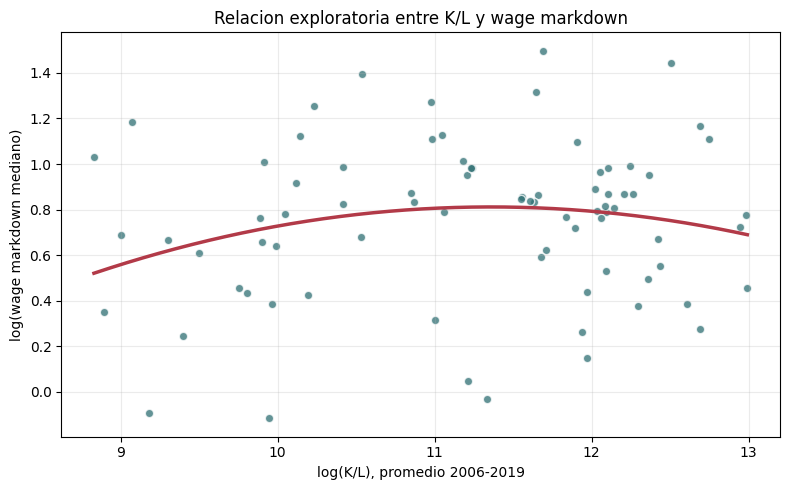

In [22]:
x = df["log_kl"]
y = df["log_markdown_p50"]
coeff = np.polyfit(x, y, deg=2)
grid = np.linspace(x.min(), x.max(), 200)
fitted = np.polyval(coeff, grid)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.75, color="#2f6f73", edgecolor="white")
plt.plot(grid, fitted, color="#b23a48", linewidth=2.5)
plt.title("Relacion exploratoria entre K/L y wage markdown")
plt.xlabel("log(K/L), promedio 2006-2019")
plt.ylabel("log(wage markdown mediano)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kl_markdown_exploratory_colab.png", dpi=180)
plt.show()

## 11. Conclusiones preliminares para el reporte

- El sistema RAG permite responder preguntas tecnicas con trazabilidad documental.
- La base empirica preliminar permite conectar el trabajo del curso con el futuro paper.
- El resultado empirico no debe presentarse como causal: por ahora solo motiva la hipotesis.
- Falta incorporar una fuente confiable de wage markdowns para paises ricos si se quiere ampliar la muestra mas alla de Amodio.
- El caso de fallo debe mostrar que el sistema no puede inferir un efecto causal exacto para Colombia 2024 si esa informacion no esta en los documentos.